In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from gps import gps, prn

# Setup

In [2]:
f_s = 4.092e6
x = np.fromfile("data/gpssim.ci16", dtype=np.int8, count=int(f_s*10))

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)

In [3]:
def psd(x, f_s):
    X = np.abs(np.fft.fft(x) ** 2 / (len(x) * f_s))
    X = 10*np.log10(X)
    X = np.fft.fftshift(X)
    f = np.linspace(f_s/-2, f_s/2, len(x))

    return f, X

# Acquisition

In [4]:
results = gps.acquisition(x, f_s, 10e3, 500, threshold=-1, verbose=True)

# Refine frequency estimates
for i in range(len(results)):
    old = results[i][1]
    results[i][1], _ = gps.fine_acquisition(x, f_s, 4096, 8, results[i][0], results[i][2], verbose=True)

    # if results[i][3] > 16:
        # print(old, results[i][1])

results = np.array(results)

[Acquisition] Searching 2.00ms period, N=8192
[Acquisition] 499.5Hz frequency bins
[Acquisition] SV: 1, Doppler shift: 3996.09Hz, Code sample phase: 775/4092, SNR: 4.2
[Acquisition] SV: 2, Doppler shift: 9990.23Hz, Code sample phase: 170/4092, SNR: 4.1
[Acquisition] SV: 3, Doppler shift: -999.02Hz, Code sample phase: 2059/4092, SNR: 12.5
[Acquisition] SV: 4, Doppler shift: 2997.07Hz, Code sample phase: 3753/4092, SNR: 8.9
[Acquisition] SV: 5, Doppler shift: -9990.23Hz, Code sample phase: 1703/4092, SNR: 3.8
[Acquisition] SV: 6, Doppler shift: -6993.16Hz, Code sample phase: 1518/4092, SNR: 4.0
[Acquisition] SV: 7, Doppler shift: -1998.05Hz, Code sample phase: 838/4092, SNR: 4.6
[Acquisition] SV: 8, Doppler shift: 5994.14Hz, Code sample phase: 574/4092, SNR: 3.8
[Acquisition] SV: 9, Doppler shift: 3496.58Hz, Code sample phase: 1208/4092, SNR: 9.5
[Acquisition] SV: 10, Doppler shift: 0.00Hz, Code sample phase: 1266/4092, SNR: 4.0
[Acquisition] SV: 11, Doppler shift: -5994.14Hz, Code sampl

## SNR

Text(0.5, 1.0, 'Acquired Satellites')

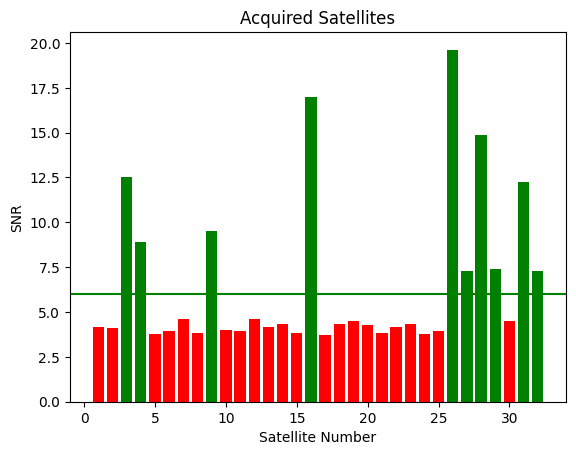

In [5]:
threshold = 6

good = results[results[:, 3] > threshold]
bad = results[results[:, 3] <= threshold]

# plt.figure(figsize=(4, 3))
plt.figure()
plt.bar(good[:, 0], good[:, 3], color='g')
plt.bar(bad[:, 0], bad[:, 3], color='r')
plt.axhline(y=threshold, zorder=-1, color='g')

plt.xlabel("Satellite Number")
plt.ylabel("SNR")
plt.title("Acquired Satellites")

## Frequency Distribution

Text(0, 0.5, 'Relative Signal Strength (dB)')

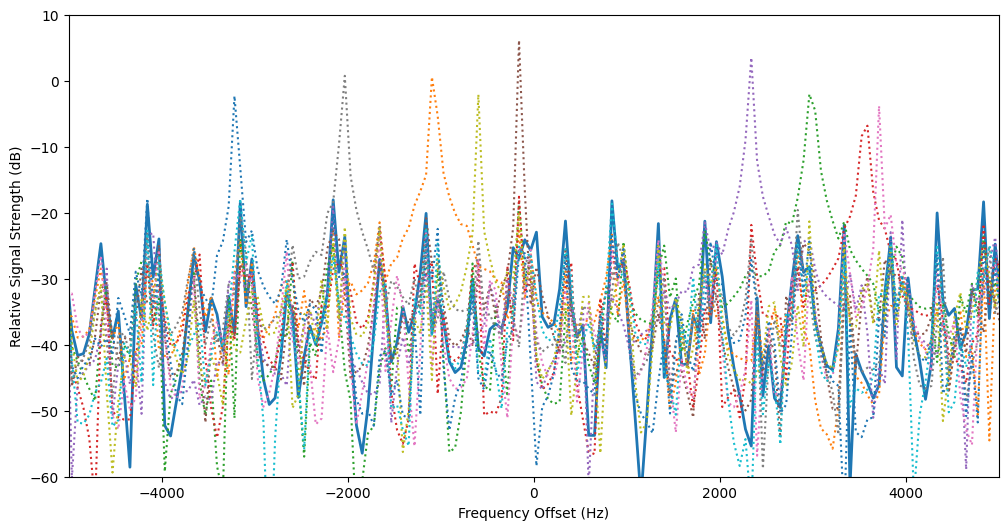

In [6]:
N = 2**16
x_samp = x[0:N]
dec = 13

plt.figure(figsize=(12, 6))
f, X = psd(signal.decimate(x_samp, dec), f_s/dec)
plt.plot(f, X, linewidth=2)

for i in range(len(good)):
    code = prn.sample(int(good[i][0]), f_s, N, offset_samples=int(good[i][2]))
    f, X = psd(signal.decimate(x_samp * code, dec), f_s/dec)
    plt.plot(f, X, ':')

plt.xlim([-5e3, 5e3])
plt.ylim([-60, 10])
plt.xlabel("Frequency Offset (Hz)")
plt.ylabel("Relative Signal Strength (dB)")

# Tracking

In [7]:
i = 0
sv = good[i][0]
freq_est = good[i][1]
code_est = good[i][2]

print(sv, freq_est, code_est)

tracking_samples = x[0:int(f_s*5)]

(
    res_iq,
    res_carr_freq,
    res_carr_err,
    res_code_freq,
    res_code_err,
    res_code_phase,
    res_code_pos,
) = gps.tracking(tracking_samples, f_s, sv, freq_est, code_est, debug_results=True)

# res_iq = res_iq / np.max(np.abs(res_iq))

3.0 -1061.7216117216158 2059.0
1.4968230694037146, (-2376-2448j), (2373.443387349127+3742.30093114221j), 4
2.4968230694037143, (-4537+4165j), (4497.930068783433-190.46549932952712j), 2
3.4968230694037143, (-3134+103j), (2856.823494572379-2718.5766217651444j), 4
4.496823069403715, (1335-1950j), (1102.221026135622-4787.898463261743j), 4
5.496823069403715, (2997+433j), (-2479.6391502113497-4227.069366810725j), 4
6.496823069403715, (-93-2694j), (-5170.336893672365+367.19952583279587j), 4
7.496823069403715, (-1699-10244j), (-346.320705522307+2789.3911915104663j), 4
8.496823069403714, (-3913-6462j), (-507.74597659156893+3787.8170181186306j), 4
9.496823069403714, (-8524+2522j), (3167.7401201006346+2570.60952397211j), 4
10.496823069403714, (-6930+246j), (3587.098586201113+1279.2799297777885j), 4
11.496823069403714, (2773-763j), (2346.7806231082272-88.36307786861369j), 4
12.496823069403714, (-143+1113j), (4096.211395151102-2404.189459592797j), 4
13.496823069403714, (-6886-2927j), (-612.46468028

(-1.05, 1.05)

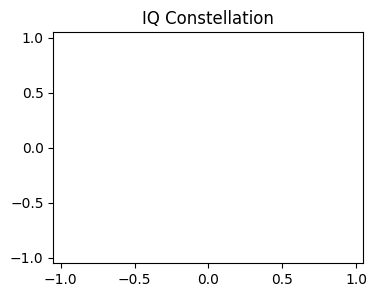

In [8]:
plt.figure(figsize=(4, 3))
plt.scatter(res_iq.real, res_iq.imag, c=np.arange(len(res_iq)))
plt.title("IQ Constellation")
# plt.xlabel("I")
# plt.ylabel("Q")
plt.xlim([-1.05, 1.05])
plt.ylim([-1.05, 1.05])

In [9]:
print(res_carr_err[0:10])
print(res_carr_freq[0:10])
print(res_iq[0:10])

[-0.1389207539878567, -0.11152627275906216, -0.12845069913285503, -0.15475807314721948, -0.15949461396925524, -0.20544410713127084, -0.21352086150460722, -0.2344209408534273, 0.23715367989095348, 0.20065506044965264]
[-1076.7359295525305, -1073.972776880616, -1075.9605710889289, -1078.9865309716417, -1079.7185707417082, -1084.911573105614, -1086.0767115122446, -1088.6392610774196, -1038.0057136941903, -1041.613102961112]
[ 6636.0913 -7911.8022j 15244.997 -12859.987j  11685.209 -12203.225j
 12172.407 -17852.719j  11796.2295-18458.066j   6409.86  -22294.904j
  5849.9272-25074.146j   2292.051 -23340.652j  -2151.012 -26591.303j
 -7291.6313-22759.65j  ]


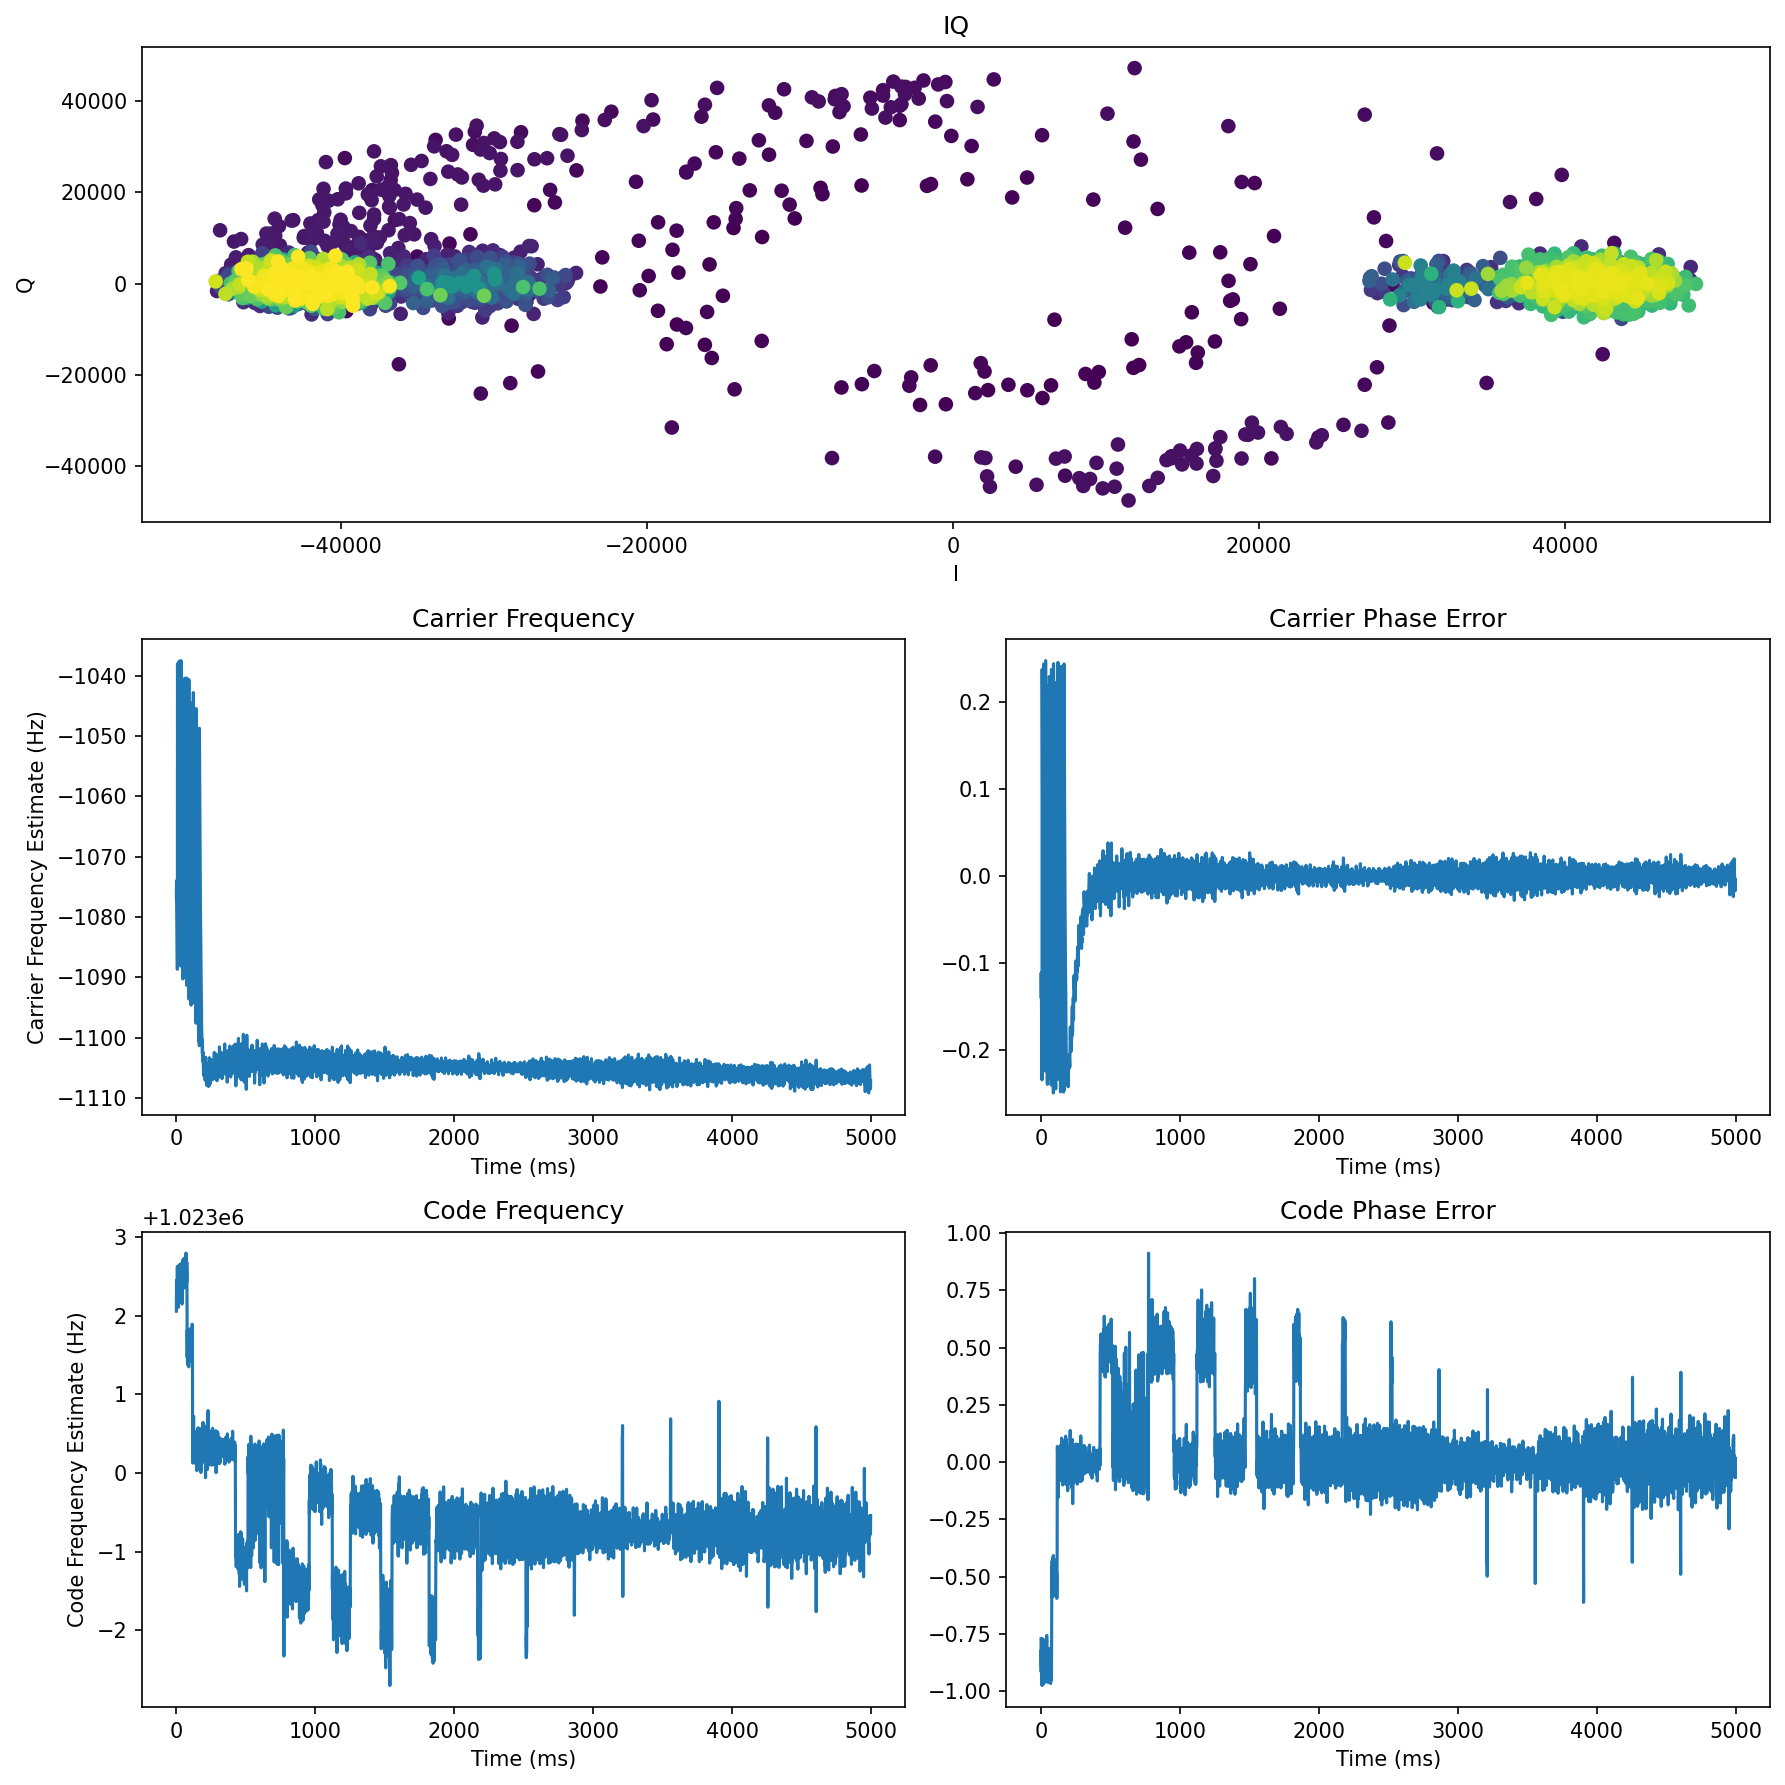

In [10]:
plt.figure(figsize=(12, 12), dpi=150)

plt.subplot(3, 2, (1, 2))
plt.scatter(res_iq.real, res_iq.imag, c=np.arange(len(res_iq)))
plt.title("IQ")
plt.xlabel("I")
plt.ylabel("Q")

plt.subplot(3, 2, 3)
plt.plot(res_carr_freq)
plt.title("Carrier Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Carrier Frequency Estimate (Hz)")

plt.subplot(3, 2, 4)
plt.plot(res_carr_err)
plt.title("Carrier Phase Error")
plt.xlabel("Time (ms)")

plt.subplot(3, 2, 5)
plt.plot(res_code_freq)
plt.title("Code Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Code Frequency Estimate (Hz)")

plt.subplot(3, 2, 6)
plt.plot(res_code_err)
plt.title("Code Phase Error")
plt.xlabel("Time (ms)")

plt.tight_layout()